# clq0.9-block phase-1 GEA replication — Manhattan grid (CORRECTED deg-2)

**Slice:** model (Kendall-tau / LFMM K=16 / binomial) x class (snp / nonsnp = sv+smallindel),
gen9 (last-gen), bio1, WZA **deg-2 canonical**, per-class SNP cap (**1000 snp / 350
nonsnp**), SD safety-floor hack removed.

**This replaces an earlier, buggy deg-2 run.** The original run had no SNP cap and
kept a "safety floor" that clipped negative-SD polynomial extrapolations (in the
sparse tail of large blocks, >~1,150 SNPs snp / >~400 nonsnp) to a value borrowed
from elsewhere on the curve — fabricating extreme significance (often literal
`Z_pVal=0`) independent of the true WZA Z. It drove **7 of the original 10**
cross-model "reproducible core" SNP blocks. Fixed by dropping the floor hack and
capping each class within its polynomial's well-supported SNP-count range
(data-driven, cross-checked against all 3 models — see `STATUS_clq90.md` sec.0).

The notebook first shows the **raw, per-record (non-WZA-aggregated) results** —
the actual input WZA consumes, before block aggregation — then the aggregated WZA
Manhattan grid, then a look at how much the snp vs nonsnp significant-block sets
overlap per model.

Each WZA point is one clq0.9 LD block at its genomic position; y = -log10(WZA
`Z_pVal`). Red dashed = Bonferroni (0.05/n_blocks); orange dotted = BH q<0.05
critical value (`q*k/m` for k BH-rejections; drawn only where k>=1). **CAM5 /
AT2G27030** (Chr2 ~11.53 Mb) is circled at its clq0.9 block **Chr2_4332** in both
classes.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

CLQ    = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/phase1_replication/clq90"
WDIR   = f"{CLQ}/wza"
WDIR_IN = f"{CLQ}/wza_in"                  # per-record input WZA actually consumes (post reblock, pre-aggregation)
CLASSES = ["snp", "nonsnp"]                # rows
MODELS  = ["kendall", "lfmm", "binomial"]  # columns
REGIME  = "deg2"
CHROMS  = [f"Chr{i}" for i in range(1, 6)]
CAM5_BLOCK = "Chr2_4332"                   # CAM5 / AT2G27030 signal block (both classes)
Q_FLOOR    = 1e-16                          # floor for plotting only; matches build_significant_genes_clq90
MAF_FILTER = 0.05                           # matches run_wza.py's --maf_filter (applied inside WZA)

def load(model, cls):
    f = f"{WDIR}/wza_{model}_{cls}_gen9_bio1_{REGIME}.csv"
    w = pd.read_csv(f).rename(columns={"index": "block"})
    w["block"] = w["block"].astype(str)
    w = w[w["Z_pVal"].notna() & w["chrom"].astype(str).isin(CHROMS)].copy()
    w["chrom"] = w["chrom"].astype(str)
    w["mlogp"] = -np.log10(w["Z_pVal"].clip(lower=Q_FLOOR))
    return w

def load_raw(model, cls):
    # per-record pval/MAF/pos fed to WZA for this (model, class) — no block aggregation
    f = f"{WDIR_IN}/{model}_{cls}_gen9_bio1.csv"
    d = pd.read_csv(f, usecols=["chrom", "pos", "MAF", "pval"])
    d = d[(d.MAF >= MAF_FILTER) & d.chrom.astype(str).isin(CHROMS)].copy()
    d["chrom"] = d["chrom"].astype(str)
    d["mlogp"] = -np.log10(d["pval"].clip(lower=Q_FLOOR))
    return d

# shared cumulative genome x-axis, from the raw per-record positions (full chrom extent,
# a superset of the WZA block-representative positions) so raw + WZA panels line up.
allpos = pd.concat([load_raw("kendall", c)[["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
GAP = 5e6
offset, off = {}, 0.0
for c in CHROMS:
    offset[c] = off; off += chrom_max[c] + GAP
ticks = [offset[c] + chrom_max[c] / 2 for c in CHROMS]
chrom_col = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}

def bh_count_crit(p, q=0.05):
    v = np.sort(np.asarray(p, float)); m = len(v)
    ok = v <= q * np.arange(1, m + 1) / m
    k = int(np.flatnonzero(ok).max() + 1) if ok.any() else 0
    return k, (q * k / m if k else np.nan)

print("loaded WZA grid:", {(m, c): len(load(m, c)) for m in MODELS for c in CLASSES})
print("loaded raw grid:", {(m, c): len(load_raw(m, c)) for m in MODELS for c in CLASSES})

loaded WZA grid: {('kendall', 'snp'): 57587, ('kendall', 'nonsnp'): 42677, ('lfmm', 'snp'): 57587, ('lfmm', 'nonsnp'): 42677, ('binomial', 'snp'): 57587, ('binomial', 'nonsnp'): 42677}


loaded raw grid: {('kendall', 'snp'): 1205512, ('kendall', 'nonsnp'): 413044, ('lfmm', 'snp'): 1205512, ('lfmm', 'nonsnp'): 413044, ('binomial', 'snp'): 1205512, ('binomial', 'nonsnp'): 413044}


## Raw (pre-WZA) per-record results

The actual per-variant input WZA aggregates into blocks — MAF>=0.05 filtered
(matching `run_wza.py`), one point per SNP/indel/SV record, y = -log10(raw model
p). This is what the WZA Manhattan below is built *from*; compare the two to see
what block-aggregation buys (and doesn't).

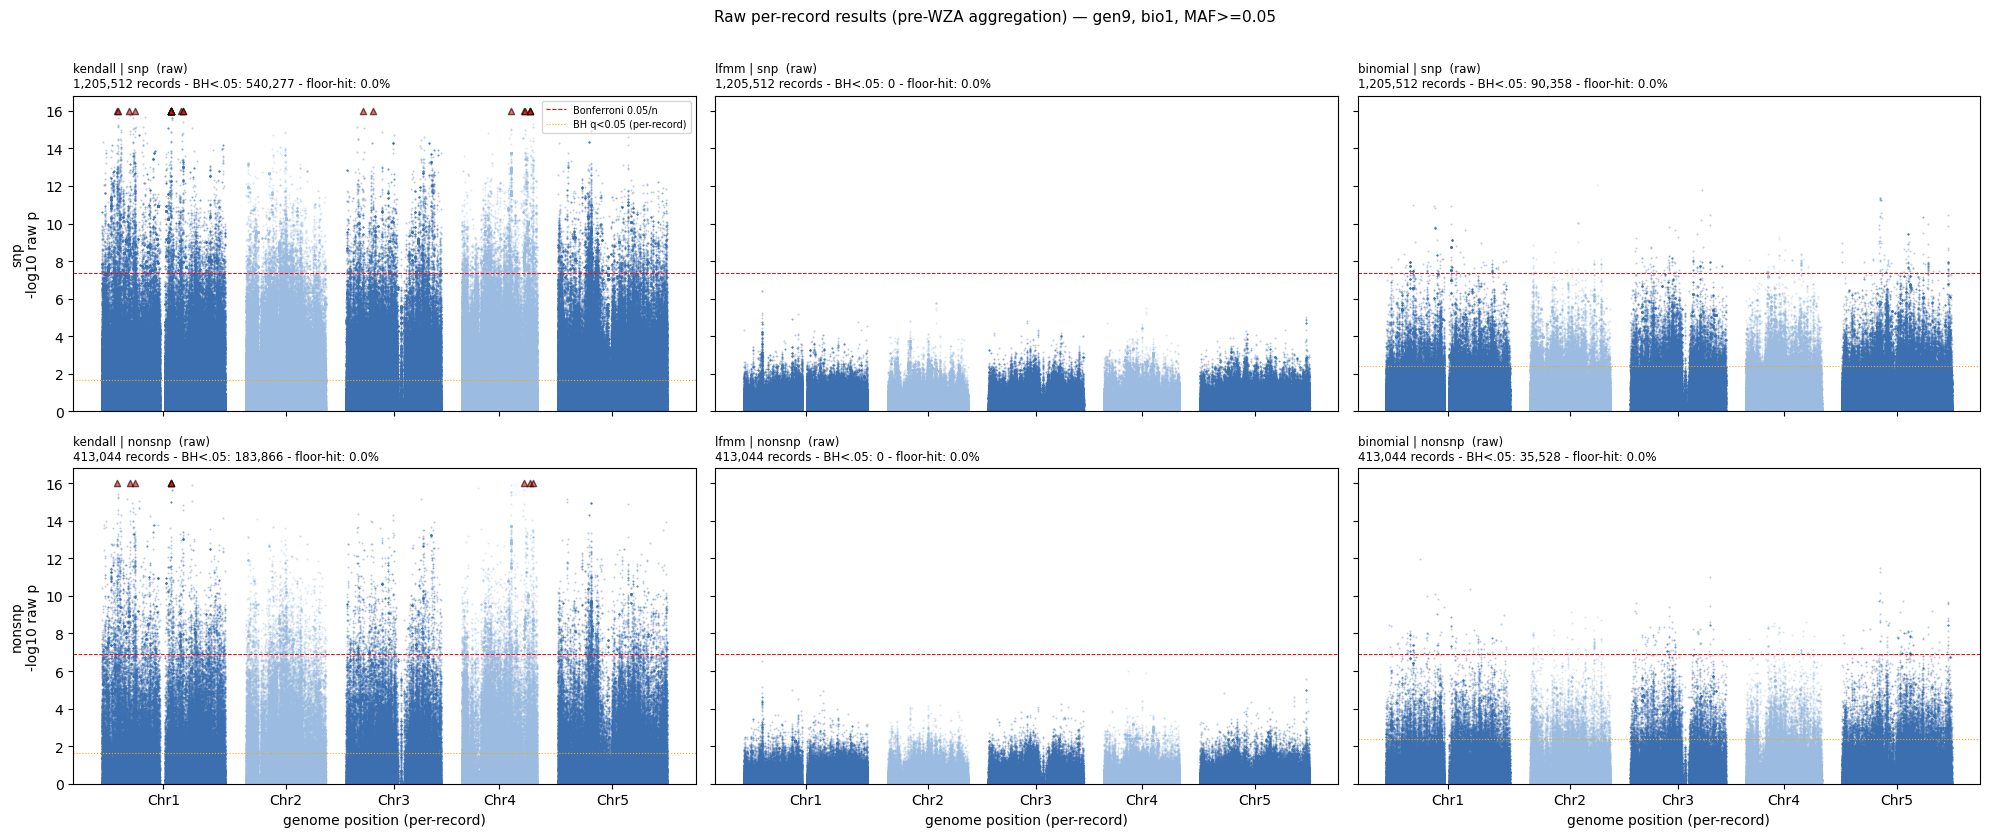

In [2]:
RAW_YMAX = -np.log10(Q_FLOOR)

fig, axes = plt.subplots(len(CLASSES), len(MODELS), figsize=(20, 8.5),
                         sharex=True, sharey=True)
for r, cls in enumerate(CLASSES):
    for cc, model in enumerate(MODELS):
        ax = axes[r, cc]
        d = load_raw(model, cls).copy()
        d["x"] = d["pos"] + d["chrom"].map(offset)
        n = len(d)
        y = d["mlogp"].clip(upper=RAW_YMAX)
        ofs = d["pval"] < Q_FLOOR          # true floor-hits, BEFORE clipping (mlogp is
                                            # already clipped, so mlogp>RAW_YMAX is never true)
        for c in CHROMS:
            m = (d["chrom"] == c) & ~ofs
            ax.scatter(d["x"][m], y[m], s=2, c=chrom_col[c], alpha=.35, linewidths=0,
                       rasterized=True)
        if ofs.any():
            ax.scatter(d["x"][ofs], np.full(int(ofs.sum()), RAW_YMAX), marker="^", s=20,
                       color="red", edgecolor="k", zorder=6, alpha=.6)
        # Bonferroni + BH q<0.05 lines on the RAW per-record p (just for reference —
        # these are per-record tests, not the block-level WZA thresholds below)
        bonf = 0.05 / n
        ax.axhline(-np.log10(bonf), color="red", lw=0.7, ls="--")
        nbh, crit = bh_count_crit(d["pval"].to_numpy())
        if nbh:
            ax.axhline(-np.log10(crit), color="orange", lw=0.8, ls=":")
        ax.set_title(f"{model} | {cls}  (raw)\n{n:,} records - BH<.05: {nbh:,} "
                     f"- floor-hit: {ofs.mean():.1%}", fontsize=8.5, loc="left")
        if cc == 0:
            ax.set_ylabel(f"{cls}\n-log10 raw p", fontsize=10)
        ax.set_ylim(0, RAW_YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS)
    ax.set_xlabel("genome position (per-record)")
axes[0, 0].plot([], [], color="red", ls="--", lw=0.8, label="Bonferroni 0.05/n")
axes[0, 0].plot([], [], color="orange", ls=":", lw=0.8, label="BH q<0.05 (per-record)")
axes[0, 0].legend(fontsize=7, loc="upper right")
fig.suptitle("Raw per-record results (pre-WZA aggregation) — gen9, bio1, MAF>=0.05", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(f"{CLQ}/manhattan_clq90_raw_grid.png", dpi=130, bbox_inches="tight")
plt.show()

## Raw p-value distribution

Histogram of the raw per-record p-values (not -log10), MAF>=0.05, with the
uniform-null expectation (dashed) for reference — the classic calibration check,
independent of any genomic position or block structure.

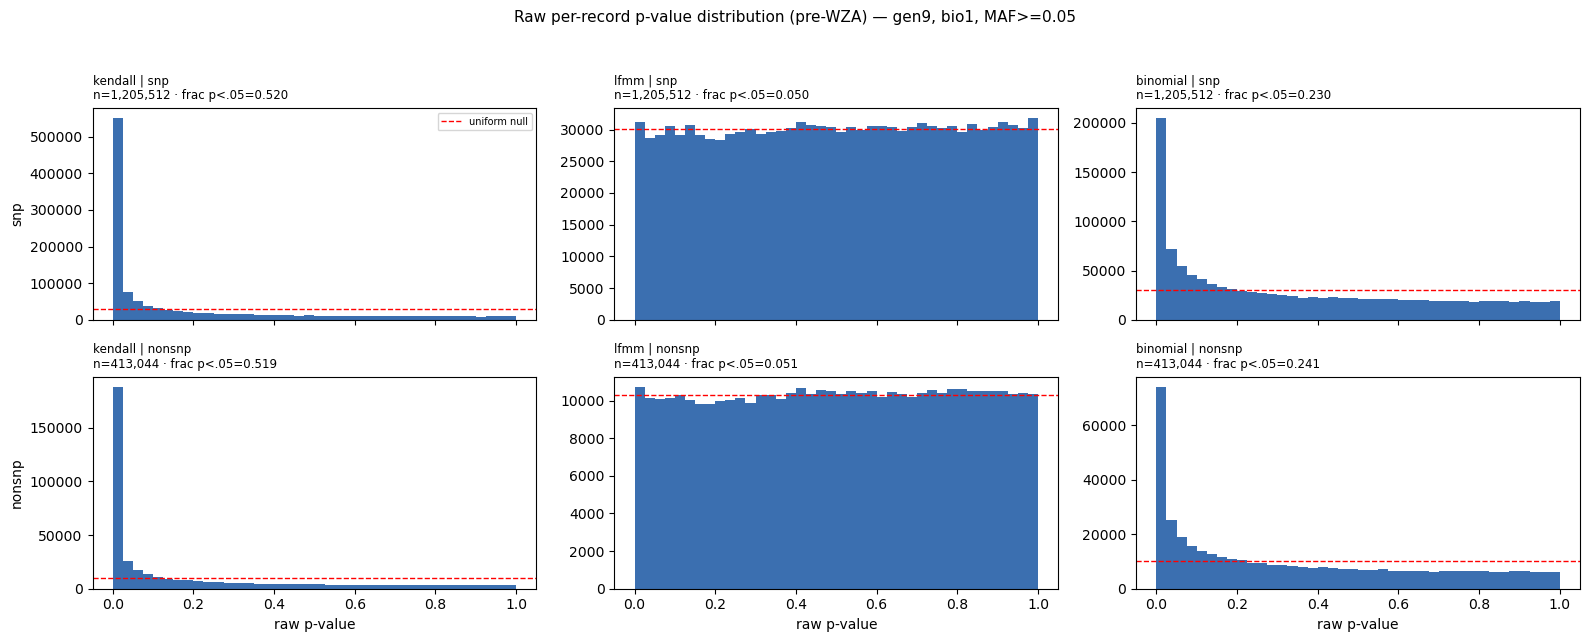

In [3]:
NBINS = 40
fig, axes = plt.subplots(len(CLASSES), len(MODELS), figsize=(16, 6.5), sharex=True)
for r, cls in enumerate(CLASSES):
    for cc, model in enumerate(MODELS):
        ax = axes[r, cc]
        d = load_raw(model, cls)
        n = len(d)
        counts, edges, _ = ax.hist(d["pval"], bins=NBINS, range=(0, 1),
                                    color=chrom_col["Chr1"], edgecolor="none")
        ax.axhline(n / NBINS, color="red", ls="--", lw=1, label="uniform null")
        frac_p05 = (d["pval"] < 0.05).mean()
        ax.set_title(f"{model} | {cls}\nn={n:,} · frac p<.05={frac_p05:.3f}", fontsize=8.5, loc="left")
        if cc == 0:
            ax.set_ylabel(cls, fontsize=10)
for ax in axes[-1, :]:
    ax.set_xlabel("raw p-value")
axes[0, 0].legend(fontsize=7)
fig.suptitle("Raw per-record p-value distribution (pre-WZA) — gen9, bio1, MAF>=0.05", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f"{CLQ}/pval_hist_clq90_raw_grid.png", dpi=130, bbox_inches="tight")
plt.show()

## Aggregated WZA Manhattan grid (CORRECTED deg-2)

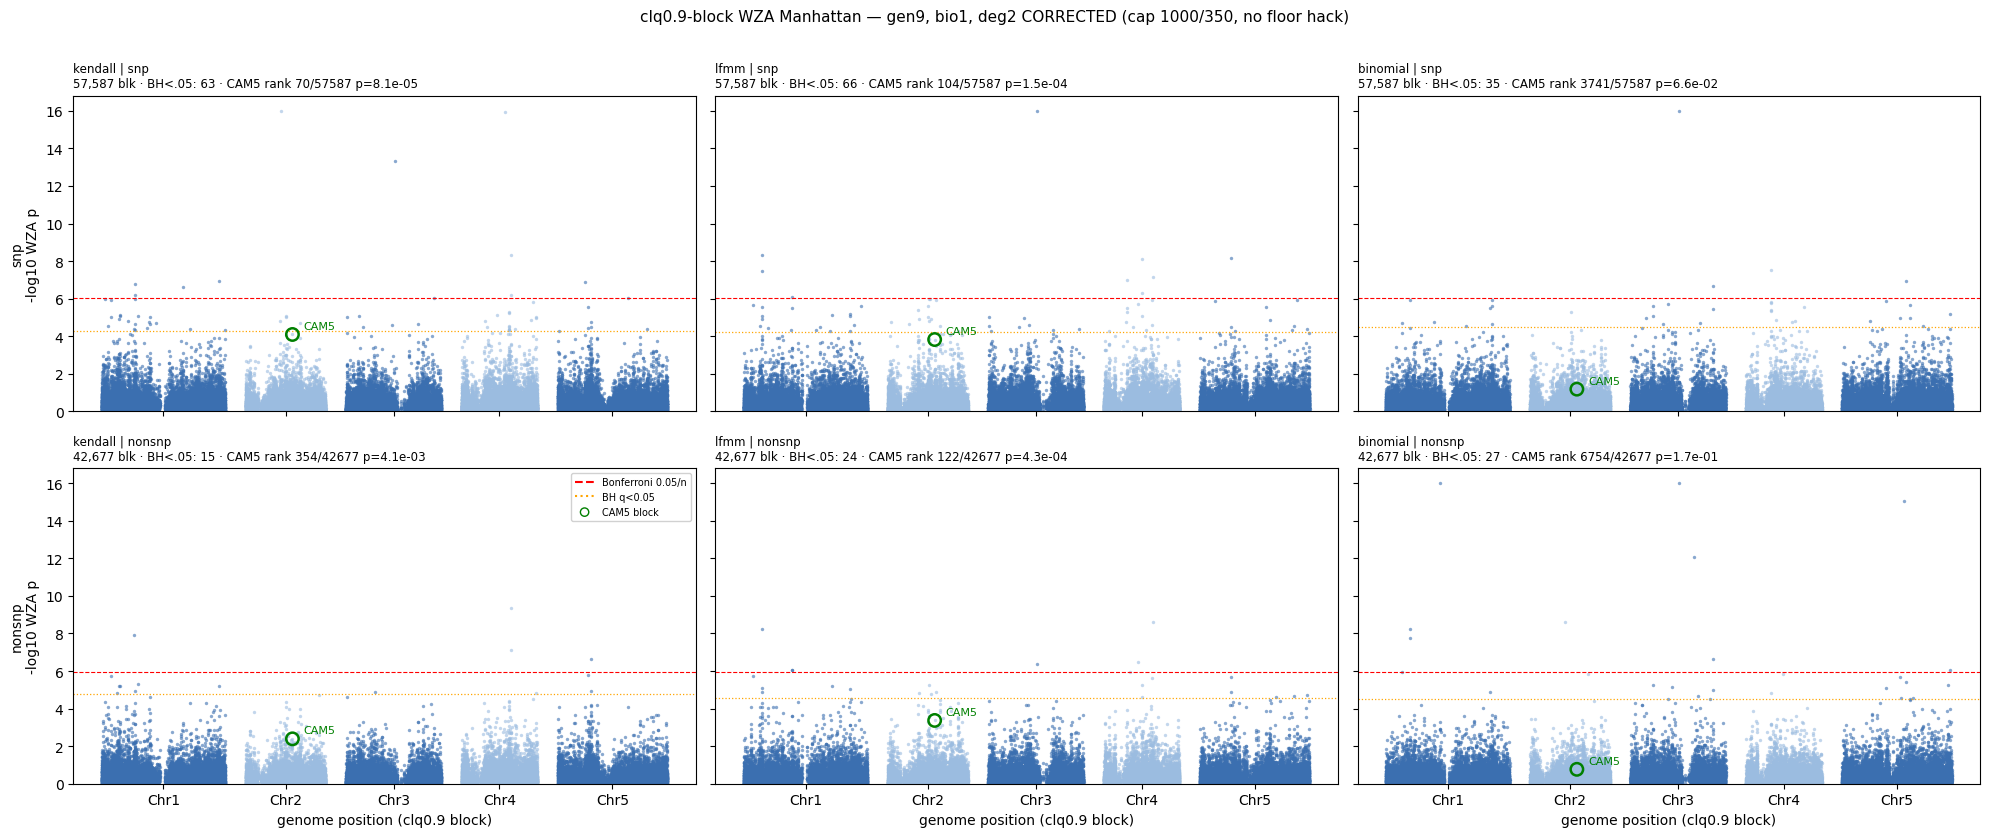

saved /global/scratch/users/tbellg/kmate/results/grenenet_gea/phase1_replication/clq90/manhattan_clq90_deg2_grid.png
saved /global/scratch/users/tbellg/kmate/results/grenenet_gea/phase1_replication/clq90/manhattan_clq90_deg2_grid.pdf


In [4]:
YMAX = -np.log10(Q_FLOOR)       # = 16: the plotting floor IS the ceiling

fig, axes = plt.subplots(len(CLASSES), len(MODELS), figsize=(20, 8.5),
                         sharex=True, sharey=True)
for r, cls in enumerate(CLASSES):
    for cc, model in enumerate(MODELS):
        ax = axes[r, cc]
        w = load(model, cls).copy()
        w["x"] = w["pos"] + w["chrom"].map(offset)
        n = len(w)
        y = w["mlogp"].clip(upper=YMAX)
        ofs = w["mlogp"] > YMAX
        for c in CHROMS:
            m = (w["chrom"] == c) & ~ofs
            ax.scatter(w["x"][m], y[m], s=6, c=chrom_col[c], alpha=.6, linewidths=0,
                       rasterized=True)
        if ofs.any():
            ax.scatter(w["x"][ofs], np.full(int(ofs.sum()), YMAX), marker="^", s=35,
                       color="red", edgecolor="k", zorder=6)
        bonf = 0.05 / n
        ax.axhline(-np.log10(bonf), color="red", lw=0.8, ls="--")
        nbh, crit = bh_count_crit(w["Z_pVal"])
        if nbh:
            ax.axhline(-np.log10(crit), color="orange", lw=0.9, ls=":")
        ws = w.sort_values("Z_pVal").reset_index(drop=True)
        cam = ws[ws["block"] == CAM5_BLOCK]
        if len(cam):
            cb = cam.iloc[0]; rank = int(ws.index[ws["block"] == CAM5_BLOCK][0]) + 1
            cy = min(cb["mlogp"], YMAX)
            ax.scatter(cb["x"], cy, s=80, facecolors="none", edgecolors="green",
                       linewidths=1.8, zorder=7)
            ax.annotate("CAM5", (cb["x"], cy), color="green", fontsize=8,
                        xytext=(8, 4), textcoords="offset points", zorder=8)
            camtxt = f" · CAM5 rank {rank}/{n} p={cb['Z_pVal']:.1e}"
        else:
            camtxt = " · CAM5 absent"
        ax.set_title(f"{model} | {cls}\n{n:,} blk · BH<.05: {nbh}{camtxt}",
                     fontsize=8.5, loc="left")
        if cc == 0:
            ax.set_ylabel(f"{cls}\n-log10 WZA p", fontsize=10)
        ax.set_ylim(0, YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS)
    ax.set_xlabel("genome position (clq0.9 block)")
axes[-1, 0].plot([], [], color="red", ls="--", label="Bonferroni 0.05/n")
axes[-1, 0].plot([], [], color="orange", ls=":", label="BH q<0.05")
axes[-1, 0].scatter([], [], facecolors="none", edgecolors="green", label="CAM5 block")
axes[-1, 0].legend(fontsize=7, loc="upper right", framealpha=0.9)
fig.suptitle("clq0.9-block WZA Manhattan — gen9, bio1, deg2 CORRECTED (cap 1000/350, no floor hack)",
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
OUT_PNG = ("/global/scratch/users/tbellg/kmate/results/grenenet_gea/"
           "phase1_replication/clq90/manhattan_clq90_deg2_grid.png")
OUT_PDF = OUT_PNG[:-4] + ".pdf"
fig.savefig(OUT_PNG, dpi=130, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight"); plt.show()
print("saved", OUT_PNG)
print("saved", OUT_PDF)

## Read-out
- No more artifactual pile-up at the -log10 p=300/1e-300 floor from the negative-SD
  bug — any block still near the plotting ceiling here reflects a genuinely
  well-fit extreme tail probability (large, capped-at-1000/350 blocks with strong
  raw Z), not a fabricated one.
- **CAM5 (Chr2_4332)** is a clear top-tier SNP block in kendall/lfmm (just below
  BH-FDR, q~0.07-0.08) and weaker in binomial/nonsnp — consistent with the
  phase-1 finding that CAM5 is primarily a SNP/3'-end signal.
- The real cross-model-reproducible core is **Chr1_2343 (GAPC2)** and
  **Chr4_6307 (CRK13-16 cluster)** — significant in all 3 models x both classes.
  Chr3_6144 (AT3G30320/UMAMIT32) is close behind (5/6 combos).

In [5]:
# compact CAM5 + BH table backing the figure
rows = []
for cls in CLASSES:
    for model in MODELS:
        ws = load(model, cls).sort_values("Z_pVal").reset_index(drop=True)
        n = len(ws); k_bh, _ = bh_count_crit(ws["Z_pVal"])
        cam = ws[ws["block"] == CAM5_BLOCK]
        cb = cam.iloc[0] if len(cam) else None
        rows.append(dict(model=model, cls=cls, n_blocks=n, n_bh=k_bh,
                         cam5_rank=(int(ws.index[ws["block"] == CAM5_BLOCK][0]) + 1) if cb is not None else None,
                         cam5_p=cb["Z_pVal"] if cb is not None else None))
pd.DataFrame(rows)

,model,cls,n_blocks,n_bh,cam5_rank,cam5_p
0,kendall,snp,57587,63,70,0.000081
1,lfmm,snp,57587,66,104,0.000150
2,binomial,snp,57587,35,3741,0.065641
3,kendall,nonsnp,42677,15,354,0.004078
4,lfmm,nonsnp,42677,24,122,0.000427
5,binomial,nonsnp,42677,27,6754,0.171081


## SNP vs nonsnp: significant-block overlap per model

clq0.9 blocks share the same genomic partition/ids across classes (`Chr{n}_{idx}`),
so a block BH-significant in **both** snp and nonsnp for the same model is a real
spatial overlap, not a coincidence of numbering. For each model: # BH-sig blocks in
snp, in nonsnp, how many are shared, and Jaccard = shared / union.

In [6]:
overlap_rows = []

def bh_sig_blocks(model, cls, q=0.05):
    w = load(model, cls).copy()
    p = w["Z_pVal"].to_numpy()
    order = np.argsort(p); m = len(p); qval = np.empty(m)
    qval[order] = np.minimum.accumulate((p[order] * m / (np.arange(m) + 1))[::-1])[::-1]
    return set(w.loc[qval < q, "block"])

for model in MODELS:
    snp_sig = bh_sig_blocks(model, "snp")
    nonsnp_sig = bh_sig_blocks(model, "nonsnp")
    shared = snp_sig & nonsnp_sig
    union = snp_sig | nonsnp_sig
    overlap_rows.append(dict(
        model=model, n_snp_sig=len(snp_sig), n_nonsnp_sig=len(nonsnp_sig),
        n_shared=len(shared), jaccard=round(len(shared) / len(union), 3) if union else np.nan,
        pct_snp_also_nonsnp=round(len(shared) / len(snp_sig), 3) if snp_sig else np.nan,
        pct_nonsnp_also_snp=round(len(shared) / len(nonsnp_sig), 3) if nonsnp_sig else np.nan))
overlap_df = pd.DataFrame(overlap_rows)
overlap_df

,model,n_snp_sig,n_nonsnp_sig,n_shared,jaccard,pct_snp_also_nonsnp,pct_nonsnp_also_snp
0,kendall,63,15,12,0.182,0.190,0.800
1,lfmm,66,24,18,0.250,0.273,0.750
2,binomial,35,27,12,0.240,0.343,0.444


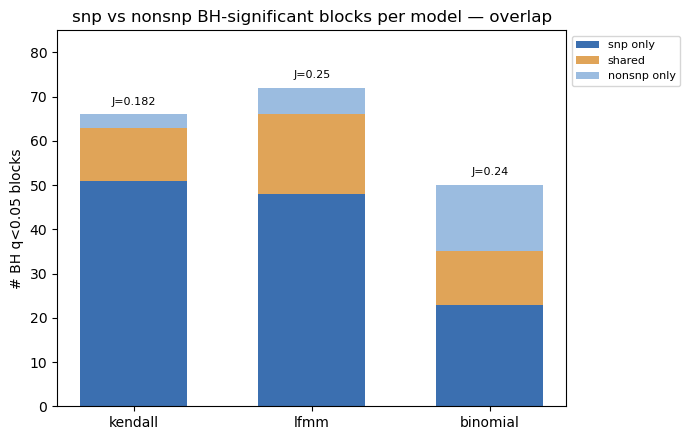

In [7]:
# grouped bar: snp-only / shared / nonsnp-only, per model
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(MODELS))
w = 0.6
snp_only = overlap_df["n_snp_sig"] - overlap_df["n_shared"]
nonsnp_only = overlap_df["n_nonsnp_sig"] - overlap_df["n_shared"]
shared = overlap_df["n_shared"]
ax.bar(x, snp_only, w, label="snp only", color="#3b6fb0")
ax.bar(x, shared, w, bottom=snp_only, label="shared", color="#e0a458")
ax.bar(x, nonsnp_only, w, bottom=snp_only + shared, label="nonsnp only", color="#9bbce0")
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel("# BH q<0.05 blocks")
ax.set_title("snp vs nonsnp BH-significant blocks per model — overlap")
ymax = (overlap_df["n_snp_sig"] + overlap_df["n_nonsnp_sig"] - overlap_df["n_shared"]).max()
ax.set_ylim(0, ymax * 1.18)
for i, row in overlap_df.iterrows():
    total = row.n_snp_sig + row.n_nonsnp_sig - row.n_shared
    ax.annotate(f"J={row.jaccard}", (i, total + ymax * 0.03), ha="center", fontsize=8)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
fig.savefig(f"{CLQ}/snp_nonsnp_overlap_clq90.png", dpi=130, bbox_inches="tight")
plt.show()

## Significant-block overlap ACROSS models (per class)

Same clq0.9 block ids are shared across models too (same partition, just scored by
a different test), so this asks the complementary question: for a given class, how
much do kendall / lfmm / binomial agree on which blocks are BH-significant? Exact
7-way breakdown (each model-only, each pairwise-only, all-3) plus the simplified
"unique to 1 / shared by 2 / shared by all 3" summary used in the bar chart.

In [8]:
from itertools import combinations

model_overlap_rows = []
for cls in CLASSES:
    sets = {m: bh_sig_blocks(m, cls) for m in MODELS}
    union = set.union(*sets.values())
    row = dict(cls=cls, n_union=len(union))
    for m in MODELS:
        row[f"n_{m}"] = len(sets[m])
    for m in MODELS:
        others = set.union(*[sets[o] for o in MODELS if o != m])
        row[f"{m}_only"] = len(sets[m] - others)
    for a, b in combinations(MODELS, 2):
        c_ = [o for o in MODELS if o not in (a, b)][0]
        row[f"{a}&{b}_only"] = len((sets[a] & sets[b]) - sets[c_])
    all3 = set.intersection(*sets.values())
    row["all_3"] = len(all3)
    row["jaccard_all3"] = round(len(all3) / len(union), 3) if union else np.nan
    model_overlap_rows.append(row)
model_overlap_df = pd.DataFrame(model_overlap_rows)
model_overlap_df

,cls,n_union,n_kendall,n_lfmm,n_binomial,kendall_only,lfmm_only,binomial_only,kendall&lfmm_only,kendall&binomial_only,lfmm&binomial_only,all_3,jaccard_all3
0,snp,146,63,66,35,49,50,31,12,0,2,2,0.014
1,nonsnp,63,15,24,27,13,21,26,2,0,1,0,0.000


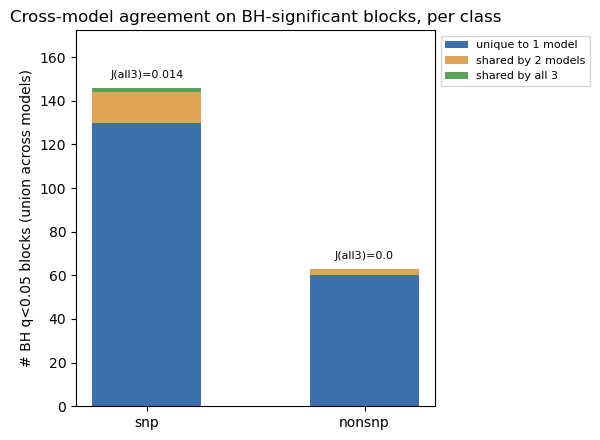

In [9]:
# simplified stacked bar per class: unique to 1 model / shared by exactly 2 / shared by all 3
fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(len(CLASSES))
w = 0.5
uniq1 = model_overlap_df[[f"{m}_only" for m in MODELS]].sum(axis=1)
pairs = [f"{a}&{b}_only" for a, b in combinations(MODELS, 2)]
shared2 = model_overlap_df[pairs].sum(axis=1)
shared3 = model_overlap_df["all_3"]
ax.bar(x, uniq1, w, label="unique to 1 model", color="#3b6fb0")
ax.bar(x, shared2, w, bottom=uniq1, label="shared by 2 models", color="#e0a458")
ax.bar(x, shared3, w, bottom=uniq1 + shared2, label="shared by all 3", color="#5aa15a")
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel("# BH q<0.05 blocks (union across models)")
ax.set_title("Cross-model agreement on BH-significant blocks, per class")
ymax = model_overlap_df["n_union"].max()
ax.set_ylim(0, ymax * 1.18)
for i, row in model_overlap_df.iterrows():
    ax.annotate(f"J(all3)={row.jaccard_all3}", (i, row.n_union + ymax * 0.03), ha="center", fontsize=8)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
fig.savefig(f"{CLQ}/model_overlap_clq90.png", dpi=130, bbox_inches="tight")
plt.show()